In [ ]:
import pandas as pd ## Thats for data managment
import matplotlib.pyplot as plt ## That's for graphical library

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/311_Service_Requests_from_2019May.csv")

/tmp/ipykernel_1035/1743695448.py:1: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/311_Service_Requests_from_2019May.csv")


In [ ]:
df.head(10)
df.tail()


,Unique Key,Created Date,Closed Date,Agency,Complaint Type,Location Type,Incident Zip,Incident Address,Street Name,Address Type,...,Landmark,Facility Type,Status,Due Date,Resolution Description,BBL,Borough,Latitude,Longitude,Location
69632,42634163,5/10/2019 0:00,5/10/2019 0:00,DOHMH,Food Poisoning,Restaurant/Bar/Deli/Bakery,10455.0,541 EAST 149 STREET,EAST 149 STREET,ADDRESS,...,NaN,NaN,Closed,5/24/2019 15:24,The Department of Health and Mental Hygiene wi...,2.022760e+09,BRONX,40.814590,-73.913892,"(40.81459022279005, -73.9138921969276)"
69633,42624568,5/10/2019 0:00,5/16/2019 0:00,DOHMH,Standing Water,1-2 Family Dwelling,10308.0,221 MAYBURY AVENUE,MAYBURY AVENUE,ADDRESS,...,NaN,NaN,Closed,6/8/2019 20:05,The Department of Health and Mental Hygiene wi...,5.051160e+09,STATEN ISLAND,40.549378,-74.140252,"(40.5493782172547, -74.14025187299927)"
69634,42638781,5/10/2019 0:00,5/10/2019 13:00,DOHMH,Food Poisoning,Restaurant/Bar/Deli/Bakery,10453.0,1824 CEDAR AVENUE,CEDAR AVENUE,ADDRESS,...,NaN,NaN,Closed,5/24/2019 10:02,The Department of Health and Mental Hygiene wi...,2.028810e+09,BRONX,40.852919,-73.919966,"(40.85291902458401, -73.9199659548619)"
69635,42637637,5/10/2019 0:00,5/10/2019 12:54,DOHMH,Food Poisoning,Restaurant/Bar/Deli/Bakery,11221.0,691 KNICKERBOCKER AVENUE,KNICKERBOCKER AVENUE,ADDRESS,...,NaN,NaN,Closed,5/24/2019 9:14,The Department of Health and Mental Hygiene wi...,3.033850e+09,BROOKLYN,40.694574,-73.910892,"(40.694573889726, -73.91089180797395)"
69636,42637636,5/10/2019 0:00,5/10/2019 12:53,DOHMH,Food Poisoning,Restaurant/Bar/Deli/Bakery,11201.0,422 FULTON STREET,FULTON STREET,ADDRESS,...,NaN,NaN,Closed,5/24/2019 7:19,The Department of Health and Mental Hygiene wi...,3.001568e+09,BROOKLYN,40.690891,-73.985951,"(40.69089111172563, -73.98595118240841)"


In [ ]:
# How many rows and columns are there in this dataset
df.shape                        #Everything
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 69637
Columns: 21


In [ ]:
# What’s the time range of this dataset
print("Start date:", df["Created Date"].min())
print("End date:", df["Created Date"].max())

Start date: 5/1/2019 0:00
End date: 5/9/2019 9:59


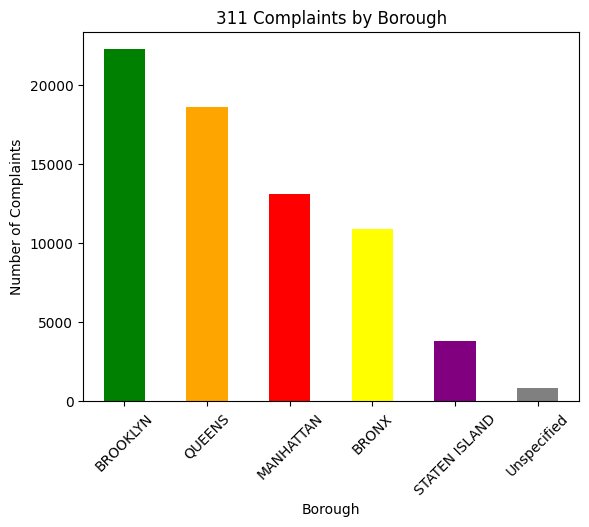

In [ ]:
# What are some relevant summary statistics
# df.describe(include="all")

# 1-Complaints by borough
borough_colors = {
    "BROOKLYN": "green",
    "QUEENS": "orange",
    "MANHATTAN": "Red",
    "BRONX": "yellow",
    "STATEN ISLAND": "purple",
    "Unspecified": "gray"
}

borough_counts = df["Borough"].value_counts()

borough_counts.plot(
    kind="bar",
    color=[borough_colors.get(borough, "gray") for borough in borough_counts.index]
)

plt.title("311 Complaints by Borough")
borough_counts = df["Borough"].value_counts()

borough_counts.plot(
    kind="bar",
    color=[borough_colors.get(borough, "gray") for borough in borough_counts.index]
)

plt.title("311 Complaints by Borough")
plt.xlabel("Borough")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45)
plt.show()


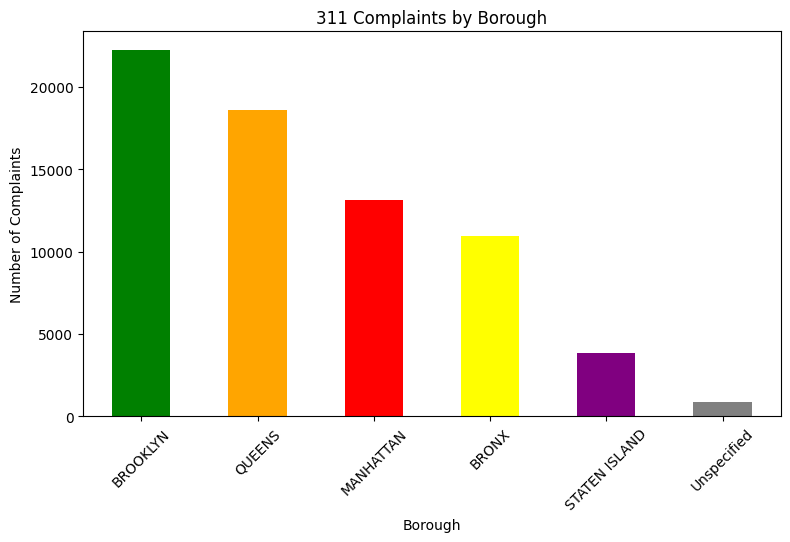

In [ ]:
#  Create 2-3 visualizations from this dataset

##
## 1. Complaints by Borough
##

borough_colors = {
    "BROOKLYN": "green",
    "QUEENS": "orange",
    "MANHATTAN": "red",
    "BRONX": "yellow",
    "STATEN ISLAND": "purple",
    "Unspecified": "gray"
}

borough_counts = df["Borough"].value_counts()

borough_counts.plot(
    kind="bar",
    color=[borough_colors.get(borough, "gray") for borough in borough_counts.index],
    figsize=(9,5)
)

plt.title("311 Complaints by Borough")
plt.xlabel("Borough")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45)
plt.show()

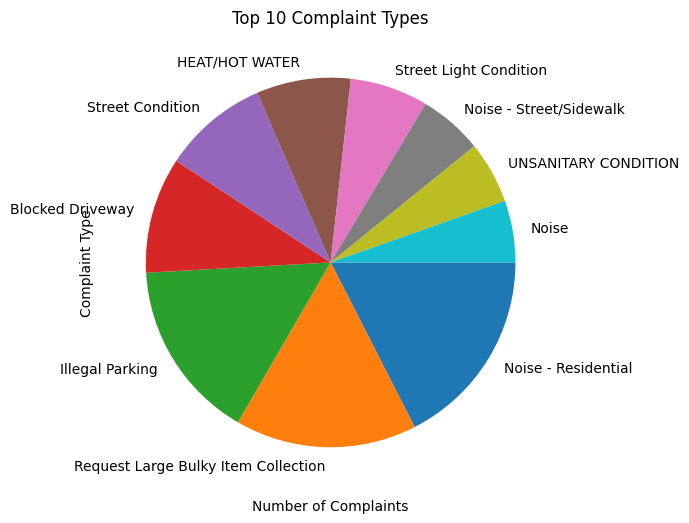

In [ ]:
##
## 2. Complaints by Borough
##

complaint_counts = df["Complaint Type"].value_counts().head(10)

complaint_counts.plot(
    kind="pie",
    figsize=(10,6)
)

plt.title("Top 10 Complaint Types")
plt.xlabel("Number of Complaints")
plt.ylabel("Complaint Type")
plt.gca().invert_yaxis()
plt.show()

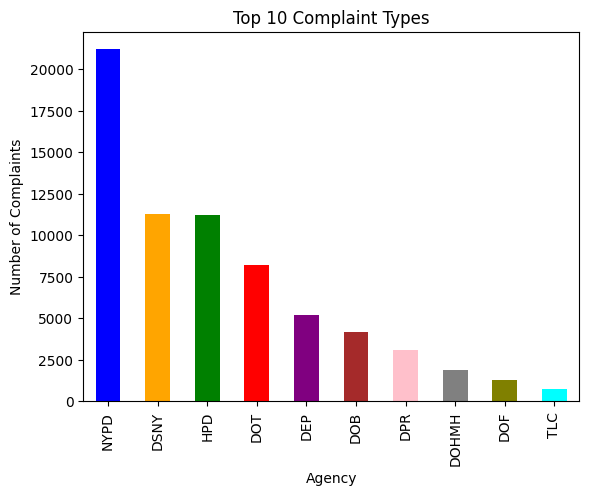

In [ ]:
##
## 3. Complaints by Borough
##

complaint_counts = df["Agency"].value_counts().head(10)

complaint_counts.plot(
    kind="bar",
    color=["blue", "orange", "green", "red", "purple", "brown", "pink", "gray", "olive", "cyan"]
)

plt.title("Top 10 Complaint Types")
plt.xlabel("Agency")
plt.ylabel("Number of Complaints")
plt.show()

In [ ]:
#5. What borough has the most complaints
df["Borough"].value_counts()



,count
Borough,
BROOKLYN,22247
QUEENS,18623
MANHATTAN,13133
BRONX,10925
STATEN ISLAND,3848
Unspecified,861


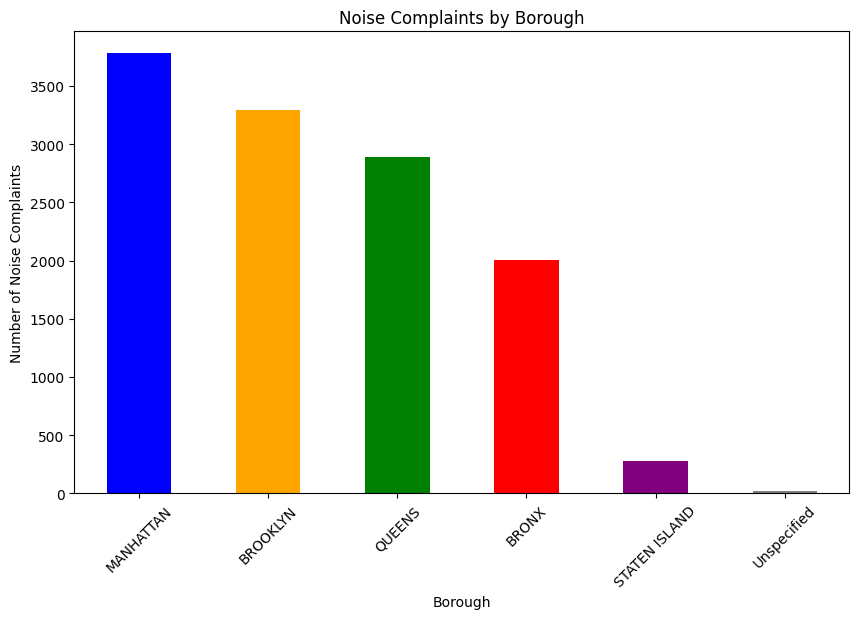

,count
Borough,
MANHATTAN,3779
BROOKLYN,3294
QUEENS,2892
BRONX,2006
STATEN ISLAND,275
Unspecified,19


In [ ]:
# Create a plot of counts by borough for noise complaints

# Filter only noise complaints
noise_df = df[
    df["Complaint Type"].str.contains(
        "Noise",
        case=False,
        na=False
    )
]

# Count noise complaints by borough
noise_borough = noise_df["Borough"].value_counts()

# See data before plot
noise_borough

# Plot
noise_borough.plot(
    kind="bar",
    figsize=(10, 6),
    color=["blue", "orange", "green", "red", "purple", "gray"]
)

plt.title("Noise Complaints by Borough")
plt.xlabel("Borough")
plt.ylabel("Number of Noise Complaints")
plt.xticks(rotation=45)

plt.show()

# See data before plot
noise_borough

In [ ]:
# Find one more interesting piece of information (anything)